In [ ]:
from diffusers import StableDiffusionPipeline
from diffusion_graph.pipeline.pipeline_compiler import DiffusionPipelineCompiler
import torch

artifact_path = "./aritfatcs_paths"
device = "cuda"
num_inference_steps = 50
tokenizer = "openai/clip-vit-large-patch14"
model_id = "runwayml/stable-diffusion-v1-5"
model_name = "compiled_sd_v1-5"
image_shape = (512, 512)
pipe = StableDiffusionPipeline.from_pretrained(
        model_id,
        torch_dtype=torch.float32,
        safety_checker=None
    )

dg_compiler = DiffusionPipelineCompiler(model_name, artifact_path, debug=False)
dg_compiler.compile(pipe, image_shape)




/home/abhishek/diffusion_graph/lib/python3.10/site-packages/torch/cuda/__init__.py:187: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12060). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0
/home/abhishek/diffusion_graph/lib/python3.10/site-packages/diffusers/models/transformers/transformer_kandinsky.py:168: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  @torch.autocast(device_type="cuda", dtype=torch.float32)
/home/abhishek/diffusion_graph/lib/python3.10/site-packages/diffusers/models/transformers/transformer_kandinsky.py:272: UserWarning: CUDA is not available or torch_xla is import

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


Compiling VAE Decoder
Completed Dynamo Export!
Processing Input Specs!


/usr/lib/python3.10/copyreg.py:101: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


In [1]:
from diffusion_graph.pipeline.pipeline_runner import DiffusionGraphRunner
import matplotlib.pyplot as plt

model_name = "compiled_sd_v1-5"
artifact_path = f"./aritfatcs_paths/{model_name}"
device = "cuda"
num_inference_steps = 50
tokenizer = "openai/clip-vit-large-patch14"
runner = DiffusionGraphRunner(artifact_path, device, num_inference_steps, tokenizer)
runner.load_pipeline()



Constructing pipeline
Loading model vae_decoder ...
Loading model text_encoder ...
Loading model unet ...


/home/abhishek/diffusion_graph/lib/python3.10/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Pipeline constructed successfully


Starting denoising process
Denoising at timestep 981
Denoising at timestep 961
Denoising at timestep 961
Denoising at timestep 941
Denoising at timestep 921
Denoising at timestep 901
Denoising at timestep 881
Denoising at timestep 861
Denoising at timestep 841
Denoising at timestep 821
Denoising at timestep 801
Denoising at timestep 781
Denoising at timestep 761
Denoising at timestep 741
Denoising at timestep 721
Denoising at timestep 701
Denoising at timestep 681
Denoising at timestep 661
Denoising at timestep 641
Denoising at timestep 621
Denoising at timestep 601
Denoising at timestep 581
Denoising at timestep 561
Denoising at timestep 541
Denoising at timestep 521
Denoising at timestep 501
Denoising at timestep 481
Denoising at timestep 461
Denoising at timestep 441
Denoising at timestep 421
Denoising at timestep 401
Denoising at timestep 381
Denoising at timestep 361
Denoising at timestep 341
Denoising at timestep 321
Denoising at timestep 301
Denoising at timestep 281
Denoising a

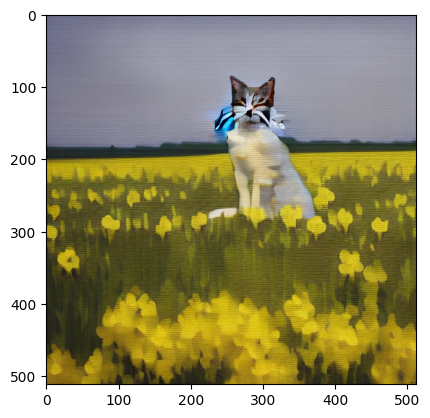

In [5]:
import matplotlib.pyplot as plt
prompt = "A yellow cat"
negative_prompt = "drawing"
image = runner.generate(prompt, negative_prompt, guidance_scale = 7.5)
plt.imshow(image)
plt.show()

Starting denoising process
Denoising at timestep 981
Denoising at timestep 961
Denoising at timestep 961
Denoising at timestep 941
Denoising at timestep 921
Denoising at timestep 901
Denoising at timestep 881
Denoising at timestep 861
Denoising at timestep 841
Denoising at timestep 821
Denoising at timestep 801
Denoising at timestep 781
Denoising at timestep 761
Denoising at timestep 741
Denoising at timestep 721
Denoising at timestep 701
Denoising at timestep 681
Denoising at timestep 661
Denoising at timestep 641
Denoising at timestep 621
Denoising at timestep 601
Denoising at timestep 581
Denoising at timestep 561
Denoising at timestep 541
Denoising at timestep 521
Denoising at timestep 501
Denoising at timestep 481
Denoising at timestep 461
Denoising at timestep 441
Denoising at timestep 421
Denoising at timestep 401
Denoising at timestep 381
Denoising at timestep 361
Denoising at timestep 341
Denoising at timestep 321
Denoising at timestep 301
Denoising at timestep 281
Denoising a

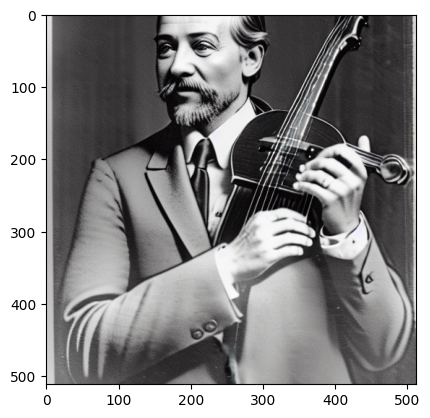

In [3]:
import matplotlib.pyplot as plt
prompt = "A man playing violin"
negative_prompt = "drawing, oil painting"
image = runner.generate(prompt, negative_prompt, do_adaptive_guidance = True, 
                            do_classifier_free_guidance = False,
                        guidance_scale = 8.5)
plt.imshow(image)
plt.show()